In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

In [14]:
# Global parameters

S0 = 5900.0
K_ATM = 5900.0
T = 3.0 # years
r = 0.04
q = 0.015
sigma = 0.18

n_paths = 50_000
n_steps = 252 * 3

dt = T/ n_steps
drift = (r - q - 0.5 * sigma**2) * dt
vol_step = sigma * np.sqrt(dt)
disc = np.exp(-r * T)

In [15]:
# Monte Carlo engine

def simulate_paths(S0, T, r, q, sigma, n_paths, n_steps):

    dt = T / n_steps

    drift = (r - q - 0.5 * sigma**2) * dt
    vol_step = sigma * np.sqrt(dt)

    Z = np.random.normal(size=(n_paths, n_steps))

    log_returns = drift + vol_step * Z

    log_paths = np.cumsum(log_returns, axis=1)

    S_paths = np.concatenate(
        [np.full((n_paths,1), S0),
         S0 * np.exp(log_paths)],
        axis=1
    )

    S_T = S_paths[:, -1]
    S_min = S_paths.min(axis=1)

    return S_paths, S_T, S_min
# Simulate once and reuse
S_paths, S_T, S_min = simulate_paths(S0, T, r, q, sigma, n_paths, n_steps)

In [16]:
# Benchmark: vanilla ATM European put
vanilla_payoff = np.maximum(K_ATM - S_T, 0.0)
vanilla_price_mc = disc * vanilla_payoff.mean()
print(f"Vanilla ATM Put (MC): {vanilla_price_mc: .4f}")

Vanilla ATM Put (MC):  484.0083


In [17]:
# Forward start time for ladder's forward leg (1Y)
t0_years = 1.0
idx_t0 = int(t0_years / dt)
S_t0 = S_paths[:, idx_t0]

In [91]:
# Strategy 1: Vanilla 3Y put spread (Long 5900, Short 80% ATM)

K_long_1 = 5900.0
K_short_1 = 0.8 * S0

pay_long_1 = np.maximum(K_long_1 - S_T, 0.0)
pay_short_1 = np.maximum(K_short_1 - S_T, 0.0)
pay_spread_1 = pay_long_1 - pay_short_1

price_spread_1 = disc * pay_spread_1.mean()
price_short_1 = disc * pay_short_1.mean()
price_long_1 = disc * pay_long_1.mean()

print("[Strategy 1: Vanilla 3Y Put Spread]")
print(f"Long K = {K_long_1:.0f}, Short K = {K_short_1:.0f}")
print(f"MC Long Price: {price_long_1:.4f}")
print(f"MC Short Price: -{price_short_1:.4f}")
print(f"MC Spread Price: {price_spread_1:.4f}")

[Strategy 1: Vanilla 3Y Put Spread]
Long K = 5900, Short K = 4720
MC Long Price: 484.0083
MC Short Price: -135.0440
MC Spread Price: 348.9643


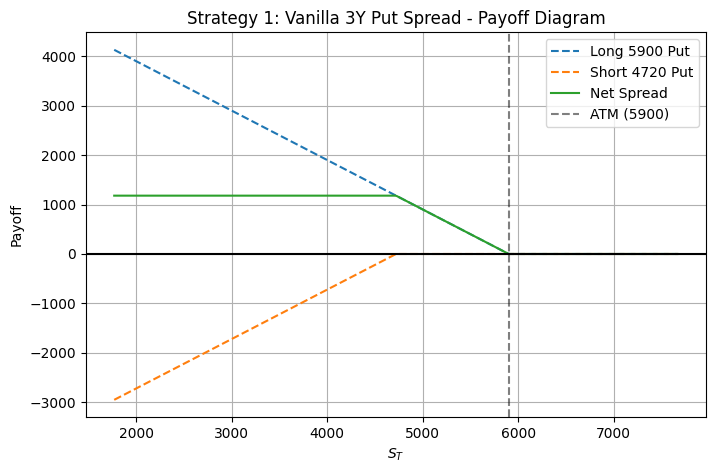

In [190]:
# Payoff diagram: Strategy 1

S_grid = np.linspace(0.3 * S0, 1.3 * S0, 400)
pay_long_grid = np.maximum(K_long_1 - S_grid, 0.0)
pay_short_grid = np.maximum(K_short_1 - S_grid, 0.0)
pay_spread_grid = pay_long_grid - pay_short_grid

plt.figure(figsize = (8,5))
plt.plot(S_grid, pay_long_grid, ls = "--", label = "Long 5900 Put")
plt.plot(S_grid, -pay_short_grid, ls = "--", label = "Short 4720 Put")
plt.plot(S_grid, pay_spread_grid, label = "Net Spread", alpha = 1)
plt.axvline(S0, color = "k", ls = "--", alpha = 0.5, label = "ATM (5900)")
plt.axhline(0, color = "k", alpha = 1)

plt.title("Strategy 1: Vanilla 3Y Put Spread - Payoff Diagram")
plt.xlabel("$S_T$")
plt.ylabel("Payoff")
plt.grid(True); plt.legend(); plt.show()

In [67]:
# Strategy 2: Down and in put (K = 5900, barrier = 5310 = -10%)

K_2 = 5900.0
H_2 = S0 * 0.9

# Knock in indicator: barrier hit at some point
knock_in = (S_min <= H_2).astype(float)

pay_di_2 = np.maximum(K_2 - S_T, 0.0) * knock_in
price_di_2 = disc * pay_di_2.mean()

print("\n[Strategy 2: Down and In Put]")
print(f"Strike K = {K_2:.0f}, Barrier H = {H_2:.0f}")
print(f"MC Price: {price_di_2:.4f}")
print(f"Knock in probability: {knock_in.mean():.4f}")


[Strategy 2: Down and In Put]
Strike K = 5900, Barrier H = 5310
MC Price: 480.7137
Knock in probability: 0.6955


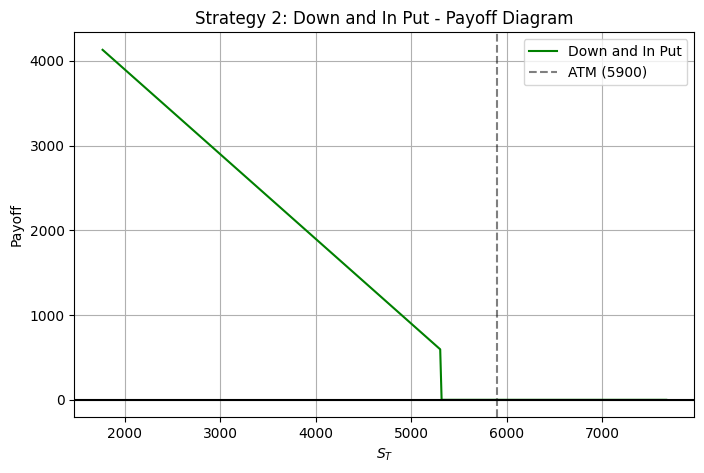

In [189]:
#payoff diagram
K_2 = 5900.0
H_2 = 0.9 * S0   # -10% barrier

knock_in_grid = (S_grid <= H_2).astype(float)
pay_di_grid = np.maximum(K_2 - S_grid, 0.0) * knock_in_grid

plt.figure(figsize=(8,5))
plt.plot(S_grid, pay_di_grid, label="Down and In Put", color="green")

plt.axvline(S0, color = "k", ls = "--", alpha = 0.5, label = "ATM (5900)")
plt.axhline(0, color = "k", alpha = 1)
plt.title("Strategy 2: Down and In Put - Payoff Diagram")
plt.xlabel("$S_T$")
plt.ylabel("Payoff")
plt.grid(True)
plt.legend()
plt.show()


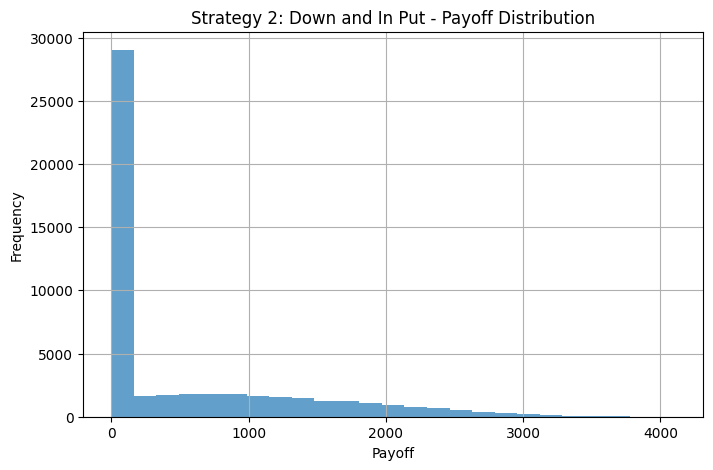

In [31]:
# Histogram showing distribution of payoffs
plt.figure(figsize =(8,5))
plt.hist(pay_di_2, bins = 25, alpha = 0.7)
plt.title("Strategy 2: Down and In Put - Payoff Distribution")
plt.xlabel("Payoff"); plt.ylabel("Frequency")
plt.grid(True); plt.show()

In [160]:
# Strategy 3: Digital put spread (Long -15%, Short -30%)

K_long_3 = 0.85 * S0
K_short_3 = 0.7 * S0

dig_long_3 = (S_T < K_long_3).astype(float)
dig_short_3 = (S_T < K_short_3).astype(float)
dig_spread_3 = ((S_T < K_long_3) & (S_T >= K_short_3)).astype(float)
dig_spread_3_1 = dig_spread_3 * digital_payout
price_dig_long_3 = disc * dig_long_3.mean() * digital_payout
price_dig_short_3 = disc * dig_short_3.mean() * digital_payout
price_dig_spread_3 = disc * dig_spread_3.mean()

digital_payout = 1000.0
price_digital_with_payout = disc * dig_spread_3.mean() * digital_payout
prob_in_zone = dig_spread_3.mean()

print("\n[Strategy 3: Digital Put Spread]")
print(f"Long digital at {K_long_3:.0f} (-15%), Short digital at {K_short_3:.0f} (-30%), Payout at {digital_payout:.0f}")
print(f"Long digital price: {price_dig_long_3:.4f}")
print(f"Short digital price: {price_dig_short_3:.4f}")
print(f"Probability $S_T$ falls in −15% to −30% zone: {prob_in_zone:.4f}")
print(f"Payout per $1: ${disc * prob_in_zone:.4f}")
print(f"Payout per ${digital_payout}: ${price_digital_with_payout:.2f}")


[Strategy 3: Digital Put Spread]
Long digital at 5015 (-15%), Short digital at 4130 (-30%), Payout at 1000
Long digital price: 237.0916
Short digital price: 95.8051
Probability $S_T$ falls in −15% to −30% zone: 0.1593
Payout per $1: $0.1413
Payout per $1000.0: $141.29


In [153]:
dig_spread_3_1

array([0., 0., 0., ..., 0., 0., 0.], shape=(50000,))

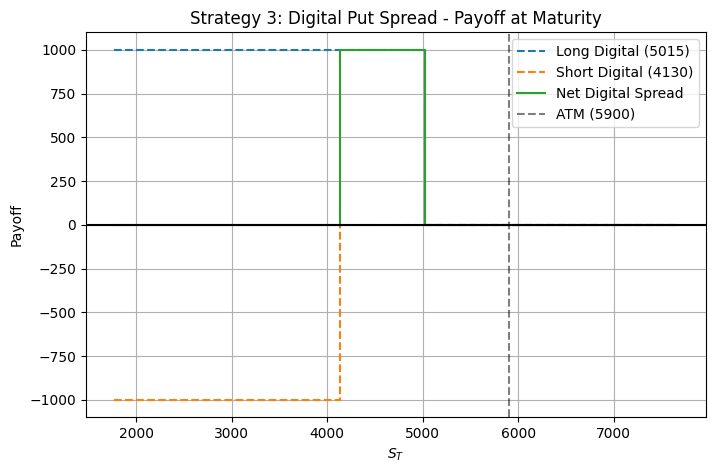

In [195]:
dig_long_grid = (S_grid < K_long_3).astype(float) * digital_payout
dig_short_grid = (S_grid < K_short_3).astype(float) * digital_payout
dig_spread_grid = dig_long_grid - dig_short_grid

plt.figure(figsize = (8,5))
plt.step(S_grid, dig_long_grid, where = "post", ls = "--", label = "Long Digital (5015)")
plt.step(S_grid, -dig_short_grid, where = "post", ls = "--", label = "Short Digital (4130)")
plt.step(S_grid, dig_spread_grid, where = "post", label = "Net Digital Spread")
plt.axvline(S0, color = "k", ls = "--", alpha = 0.5, label = "ATM (5900)")
plt.axhline(0, color = "k", alpha = 1)
plt.title("Strategy 3: Digital Put Spread - Payoff at Maturity")
plt.xlabel("$S_T$"); plt.ylabel("Payoff")
plt.grid(True); plt.legend(); plt.show()

In [116]:
# Strategy 4: Forward Ladder

# 50% 3Y put spread (already computed earlier)
# pay_spread_1  = long 5900 put - short 80% put
# price_spread_1_0 = disc * pay_spread_1.mean()

# --- Forward-starting 2Y put spread (starts at t0 = 1Y, matures at T = 3Y) ---

# Forward-start strikes
K_long_fwd  = S_t0
K_short_fwd = 0.8 * S_t0     # short strike is 80% of S_t0 (forward ATM)

# Pathwise payoff at maturity (T = 3Y)
pay_long_fwd  = np.maximum(K_long_fwd  - S_T, 0.0)
pay_short_fwd = np.maximum(K_short_fwd - S_T, 0.0)
pay_spread_fwd = pay_long_fwd - pay_short_fwd

# Price at t0 (1Y): discount 2 years
price_spread_fwd_t0 = np.exp(-r * (T - t0_years)) * pay_spread_fwd.mean()

# Price today (0Y): discount 1 more year
price_spread_fwd_0 = np.exp(-r * t0_years) * price_spread_fwd_t0
# This simplifies to:
# price_spread_fwd_0_vec = np.exp(-r * T) * pay_spread_fwd.mean()
# price_spread_fwd_0_vec = disc * pay_spread_fwd.mean()

# Ladder payoff (combine payoffs, NOT prices) 
pay_ladder_4 = 0.5 * pay_spread_1 + 0.5 * pay_spread_fwd

# Price ladder at time 0
price_ladder_4 = disc * pay_ladder_4.mean()

# --- Print results ---
print("\n[Strategy 4: Forward Ladder]")
print(f"3Y Put Spread Price (50%): ${0.5 * price_spread_1:.4f}")
print(f"Forward 2Y Put Spread Price (50%): ${0.5 * price_spread_fwd_0:.4f}")
print(f"Total Ladder Price: ${price_ladder_4:.4f}")



[Strategy 4: Forward Ladder]
3Y Put Spread Price (50%): $174.4821
Forward 2Y Put Spread Price (50%): $169.1193
Total Ladder Price: $343.6014


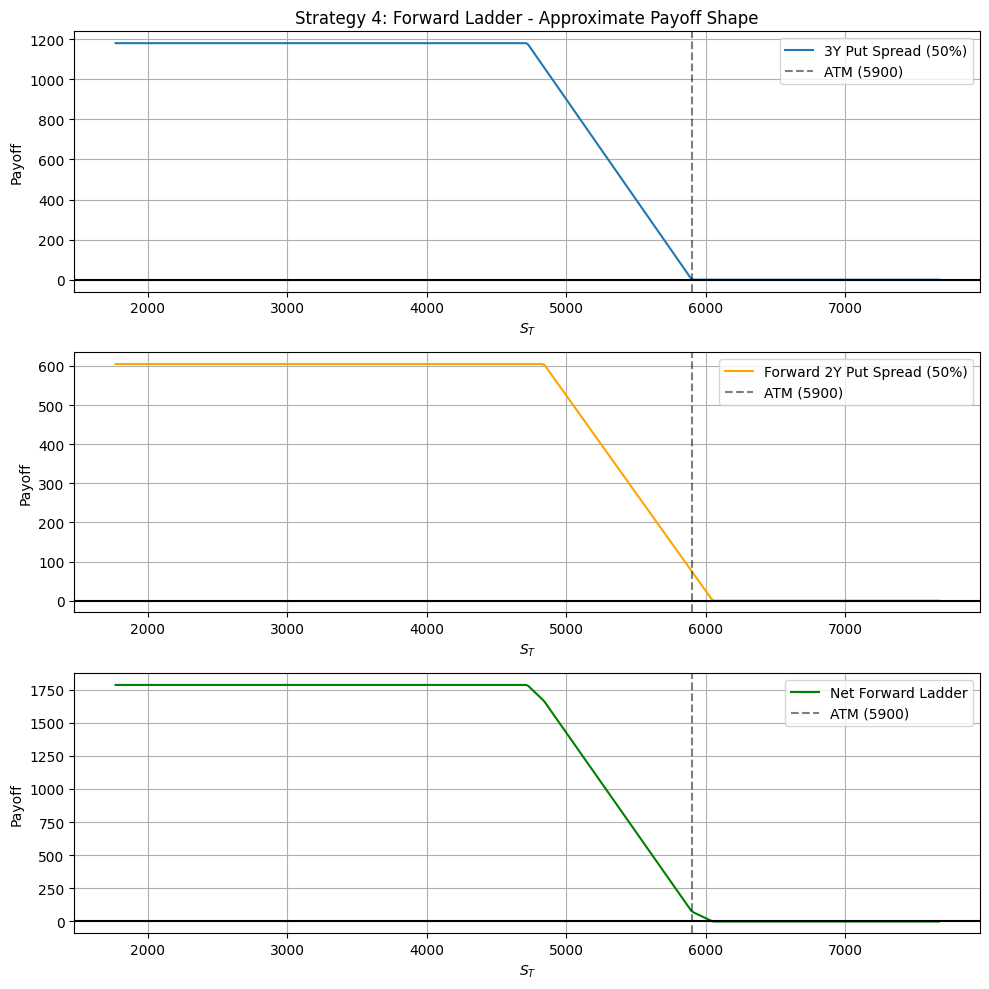

In [196]:
# Approximate payoff diagram (treating forward short strike as 0.8 * S0 just for shape)

E_S_t0 = S0 * np.exp((r - q) * t0_years)   # expected forward price at t0
K_long_fwd_approx  = E_S_t0
K_short_fwd_approx = 0.8 * E_S_t0

pay_spread_fwd_grid = (
    np.maximum(K_long_fwd_approx  - S_grid, 0.0)
    - np.maximum(K_short_fwd_approx - S_grid, 0.0)
)
pay_spread_fwd_grid_50 = 0.5 * pay_spread_fwd_grid
pay_spread_grid_50 = pay_spread_grid

# Net Ladder Payoff
pay_ladder_grid = pay_spread_grid_50 + pay_spread_fwd_grid_50

plt.figure(figsize = (10,10))

plt.subplot(3,1,1)
plt.title("Strategy 4: Forward Ladder - Approximate Payoff Shape")
plt.plot(S_grid, pay_spread_grid_50, label = "3Y Put Spread (50%)")
plt.axvline(S0, color = "k", ls = "--", alpha = 0.5, label = "ATM (5900)")
plt.axhline(0, color = "k", alpha = 1)
plt.xlabel("$S_T$"); plt.ylabel("Payoff")
plt.grid(True); plt.legend()

plt.subplot(3,1,2)
plt.plot(S_grid, pay_spread_fwd_grid_50, color = "orange", label = "Forward 2Y Put Spread (50%)")
plt.axvline(S0, color = "k", ls = "--", alpha = 0.5, label = "ATM (5900)")
plt.axhline(0, color = "k", alpha = 1)
plt.xlabel("$S_T$"); plt.ylabel("Payoff")
plt.grid(True); plt.legend()

plt.subplot(3,1,3)
plt.plot(S_grid, pay_ladder_grid, color = "green", label = "Net Forward Ladder")
plt.axvline(S0, color = "k", ls = "--", alpha = 0.5, label = "ATM (5900)")
plt.axhline(0, color = "k", alpha = 1)
plt.xlabel("$S_T$"); plt.ylabel("Payoff")
plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

In [174]:
#Scenario Analysis for all four strategies

# Scenarios on S_T vs S0
scen_ST = {
    "Crash": (S_T <= 0.6 * S0),
    "Downturn": (S_T > 0.6 * S0) & (S_T <= 0.8 * S0),
    "Slow Decline": (S_T > 0.8 * S0) & (S_T <= 0.95 * S0),
    "Sideways": (S_T > 0.95 * S0) & (S_T <= 1.05 * S0),
    "Rally": (S_T > 1.05 * S0)
}

#Scenarios for digital strikes
scen_digital = {
    "Crash": (S_T < K_short_3),
    "Digital Zone": (S_T >= K_short_3) & (S_T < K_long_3),
    "Above": (S_T >= K_long_3)
}

# Scenarios on forward return S_T / S0
R_t0T = S_T / S_t0
scen_forward = {
    "Crash after $t_0$": (R_t0T <= 0.6),
    "Downturn after $t_0$": (R_t0T > 0.60) & (R_t0T <= 0.8),
    "Slow Decline after $t_0$": (R_t0T > 0.8) & (R_t0T <= 0.95),
    "Sideways after $t_0$": (R_t0T > 0.95) & (R_t0T <= 1.05),
    "Rally after $t_0$": (R_t0T > 1.05)
}

def scen_avg(masks, *paths):
    out = {}
    for name, m in masks.items():
        if m.sum() == 0:
            out[name] = [0.0 for _ in paths]
        else:
            out[name] = [p[m].mean() for p in paths]
    return out

# Strategy 1
sc1 = scen_avg(scen_ST, pay_long_1, pay_short_1, pay_spread_1)

# Strategy 2
sc2 = scen_avg(scen_ST, pay_di_2)

# Strategy 3
sc3 = scen_avg(scen_digital, dig_spread_3_1)

# Strategy 4
sc4 = scen_avg(scen_forward, pay_spread_1 * 0.5, pay_spread_fwd * 0.5, pay_ladder_4)

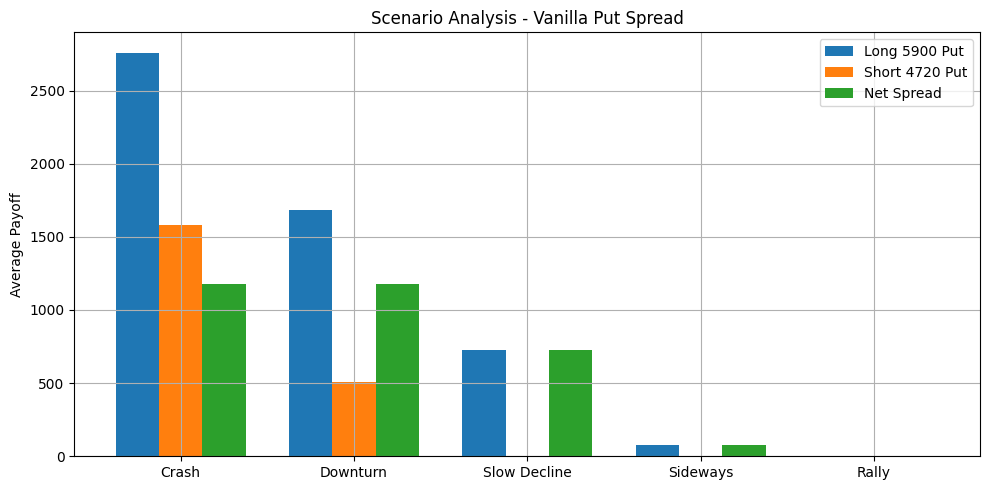

In [191]:
# Bar chart: Strategy 1
labels1 = list(sc1.keys()); x = np.arange(len(labels1)); w = 0.25
plt.figure(figsize = (10,5))
plt.bar(x - w, [sc1[k][0] for k in labels1], w, label = "Long 5900 Put")
plt.bar(x, [sc1[k][1] for k in labels1], w, label = "Short 4720 Put")
plt.bar(x + w, [sc1[k][2] for k in labels1], w, label = "Net Spread")
plt.xticks(x, labels1); plt.title("Scenario Analysis - Vanilla Put Spread")
plt.ylabel("Average Payoff"); plt.grid(True); plt.legend(); plt.tight_layout();plt.show()

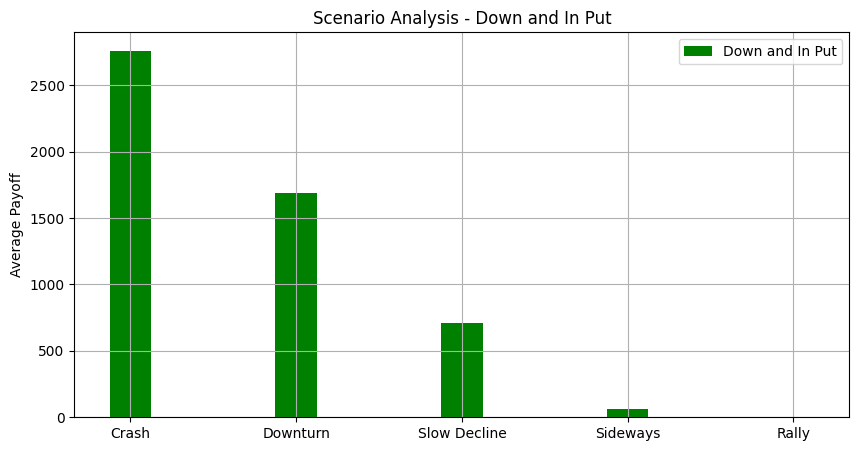

In [176]:
# Strategy 2
labels2 = list(sc2.keys()); x2 = np.arange(len(labels2))
plt.figure(figsize = (10,5))
plt.bar(x2, [sc2[k][0] for k in labels2], w, color = "green", label = "Down and In Put")
plt.xticks(x2, labels2); plt.title("Scenario Analysis - Down and In Put")
plt.ylabel("Average Payoff"); plt.grid(True); plt.legend(); plt.show()

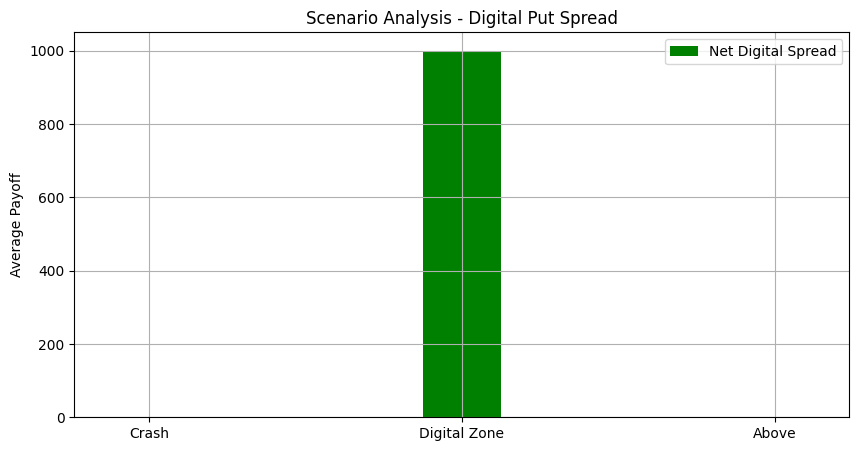

In [194]:
# Strategy 3
labels3 = list(sc3.keys()); x3 = np.arange(len(labels3))
plt.figure(figsize = (10,5))
#plt.bar(x3 - w, [sc3[k][0] for k in labels3], w, label = "Long Digital (-15%)")
#plt.bar(x3, [sc3[k][1] for k in labels3], w, label = "Short Digital (-30%)")
plt.bar(x3, [sc3[k][0] for k in labels3], w, color = "green", label = "Net Digital Spread")
plt.xticks(x3, labels3); plt.title("Scenario Analysis - Digital Put Spread")
plt.ylabel("Average Payoff"); plt.grid(True); plt.legend(); plt.show()

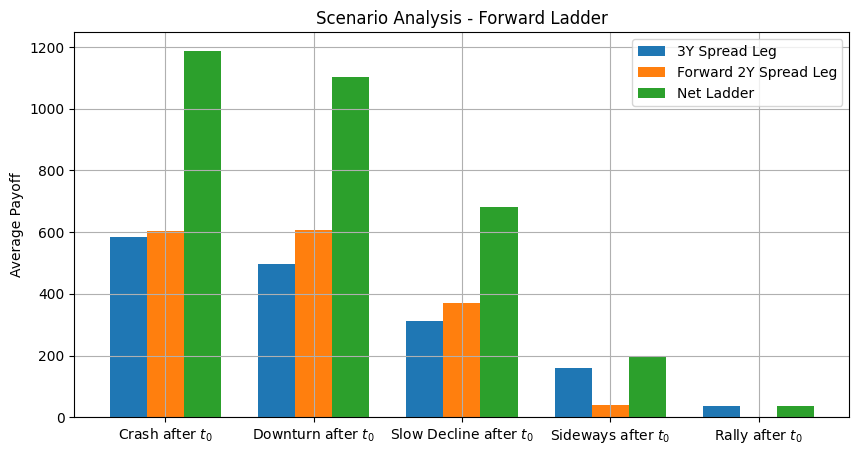

In [177]:
labels4 = list(sc4.keys()); x4 = np.arange(len(labels4))
plt.figure(figsize = (10,5))
plt.bar(x4 - w, [sc4[k][0] for k in labels4], w, label = "3Y Spread Leg")
plt.bar(x4, [sc4[k][1] for k in labels4], w, label = "Forward 2Y Spread Leg")
plt.bar(x4 + w, [sc4[k][2] for k in labels4], w, label = "Net Ladder")
plt.xticks(x4, labels4); plt.title("Scenario Analysis - Forward Ladder")
plt.ylabel("Average Payoff"); plt.grid(True); plt.legend(); plt.show()

In [180]:
import pandas as pd

In [183]:
# Summary table
print("\n" + "="*70)
print("STRATEGY COST COMPARISON")
print("="*70)
summary_df = pd.DataFrame({
    'Strategy': [
        'Vanilla ATM Put (Baseline)',
        'Down-and-In Put (−10% barrier)',
        'Digital Spread (−15% to −30%)',
        'Forward Ladder (50/50)',
        'Vanilla Put Spread (L ATM / S −20%)'
    ],
    'Price': [
        f"${vanilla_price_mc:.2f}",
        f"${price_di_2:.2f}",
        f"${price_digital_with_payout:.2f}",
        f"${price_ladder_4:.2f}",
        f"${price_spread_1:.2f}"
    ],
    'Cost Savings': [
        "0%",
        f"{(vanilla_price_mc - price_di_2) / vanilla_price_mc * 100:.1f}%",
        f"{(vanilla_price_mc - price_digital_with_payout) / vanilla_price_mc * 100:.1f}%",
        f"{(vanilla_price_mc - price_ladder_4) / vanilla_price_mc * 100:.1f}%",
        f"{(vanilla_price_mc - price_spread_1) / vanilla_price_mc * 100:.1f}%"
    ]
})
print(summary_df.to_string(index=False))


STRATEGY COST COMPARISON
                           Strategy   Price Cost Savings
         Vanilla ATM Put (Baseline) $484.01           0%
     Down-and-In Put (−10% barrier) $480.71         0.7%
      Digital Spread (−15% to −30%) $141.29        70.8%
             Forward Ladder (50/50) $343.60        29.0%
Vanilla Put Spread (L ATM / S −20%) $348.96        27.9%


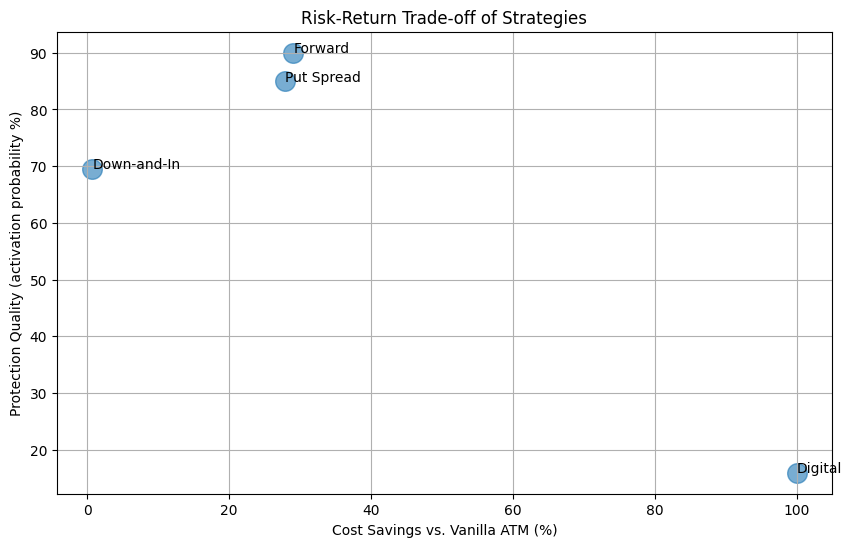

In [197]:
# Risk matrix: Cost savings vs. Protection quality
import matplotlib.pyplot as plt

strategies = ['Down-and-In', 'Digital', 'Forward', 'Put Spread']
cost_savings = [
    (vanilla_price_mc - price_di_2) / vanilla_price_mc * 100,
    (vanilla_price_mc - price_dig_spread_3) / vanilla_price_mc * 100,
    (vanilla_price_mc - price_ladder_4) / vanilla_price_mc * 100,
    (vanilla_price_mc - price_spread_1) / vanilla_price_mc * 100
]
# Protection "quality" could be: probability of protection triggering, or ratio of max payout to cost
protection_quality = [
    knock_in.mean() * 100,  # % chance barrier is hit
    dig_spread_3.mean() * 100,  # % chance digital pays
    90,  # Forward ladder covers 90% of 3Y
    85  # Put spread covers 85% (up to −20%)
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(cost_savings, protection_quality, s=200, alpha=0.6)
for i, strat in enumerate(strategies):
    ax.annotate(strat, (cost_savings[i], protection_quality[i]))
ax.set_xlabel("Cost Savings vs. Vanilla ATM (%)")
ax.set_ylabel("Protection Quality (activation probability %)")
ax.set_title("Risk-Return Trade-off of Strategies")
ax.grid(True)
plt.show()